## Read Data

In [1]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/TelConnect Battle Against Churn/Telconnect data.csv')
df.head()

,customerID,gender,SeniorCitizen,Has_Partner,Has_Dependents,account_tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Has_Partner       7043 non-null   object 
 4   Has_Dependents    7043 non-null   object 
 5   account_tenure    7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Quick conversion

#### Data Type Conversion

In [5]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [6]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# convert churn to binary for easier analysis
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0})

In [7]:
# Convert categorical columns to category dtype
categorical_columns = [
    "gender", "Has_Partner", "Has_Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "Churn"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

df["SeniorCitizen"] = df["SeniorCitizen"].astype("category")

#### Missing Value Assessment

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Has_Partner       7043 non-null   category
 4   Has_Dependents    7043 non-null   category
 5   account_tenure    7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

In [9]:
df_all = df.copy()
df_churn = df[df["Churn"] == "Yes"].copy()
df_retained = df[df["Churn"] == "No"].copy()

df_all.info()
df_churn.info()
df_retained.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Has_Partner       7043 non-null   category
 4   Has_Dependents    7043 non-null   category
 5   account_tenure    7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 n

In [10]:
df_all.describe()

,account_tenure,MonthlyCharges,TotalCharges,Churn_Flag
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,0.265370
std,24.559481,30.090047,2266.771362,0.441561
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.850000,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


In [11]:
df_churn.describe()

,account_tenure,MonthlyCharges,TotalCharges,Churn_Flag
count,1869.000000,1869.000000,1869.000000,1869.0
mean,17.979133,74.441332,1531.796094,1.0
std,19.531123,24.666053,1890.822994,0.0
min,1.000000,18.850000,18.850000,1.0
25%,2.000000,56.150000,134.500000,1.0
50%,10.000000,79.650000,703.550000,1.0
75%,29.000000,94.200000,2331.300000,1.0
max,72.000000,118.350000,8684.800000,1.0


## Exploratory Data Analysis (EDA)

#### Overall Churn Rate Distribution

In [12]:
churn_rate = df["Churn_Flag"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 26.54%


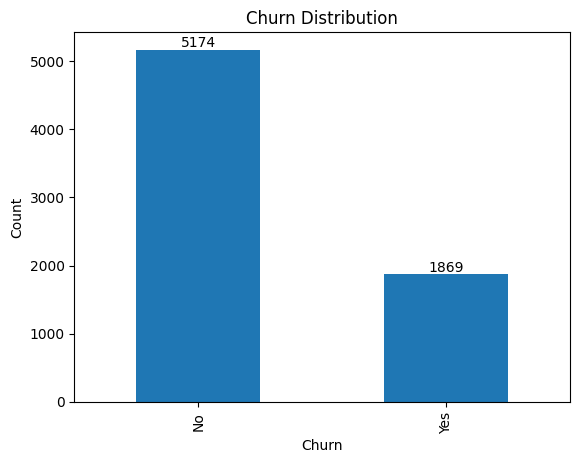

In [13]:
import matplotlib.pyplot as plt

ax = df["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

In [14]:
summary = pd.DataFrame({
    "All_Customers": df_all.mean(numeric_only=True),
    "Churned_Customers": df_churn.mean(numeric_only=True)
})

summary["Difference"] = summary["Churned_Customers"] - summary["All_Customers"]

summary.sort_values("Difference", ascending=False)

,All_Customers,Churned_Customers,Difference
MonthlyCharges,64.761692,74.441332,9.679640
Churn_Flag,0.265370,1.000000,0.734630
account_tenure,32.371149,17.979133,-14.392015
TotalCharges,2283.300441,1531.796094,-751.504347


In [15]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove("Churn_Flag")  # remove target

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features.remove("customerID")  # remove ID if present
categorical_features.remove("Churn")       # remove original target

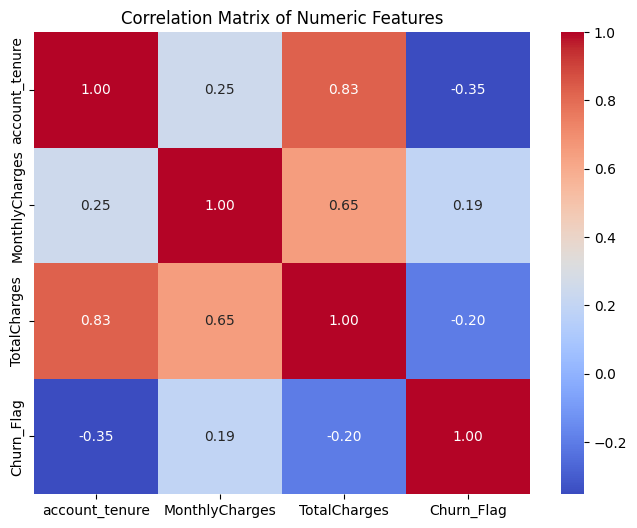

In [16]:
correlation_matrix = df[numeric_features + ["Churn_Flag"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

#### Numeric Feature Distribution Comparison (Churn vs. Non-Churn)

In [17]:
def compare_distribution(df, column):
    plt.figure()
    sns.kdeplot(df[df["Churn_Flag"] == 0][column], label="No Churn")
    sns.kdeplot(df[df["Churn_Flag"] == 1][column], label="Churn")
    sns.kdeplot(df[column], label="All Customer")
    plt.title(f"{column} Distribution: Churn vs Non-Churn")
    plt.legend()
    plt.show()

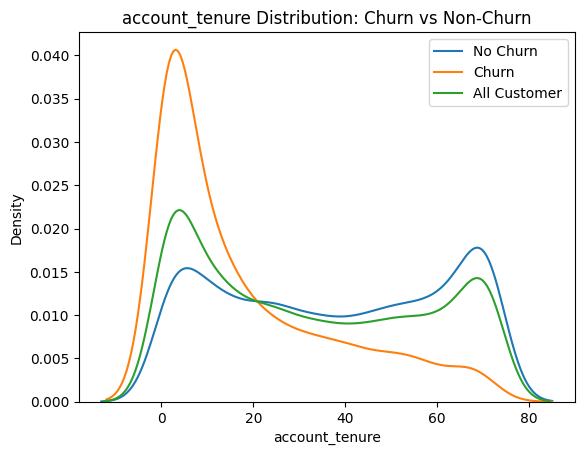

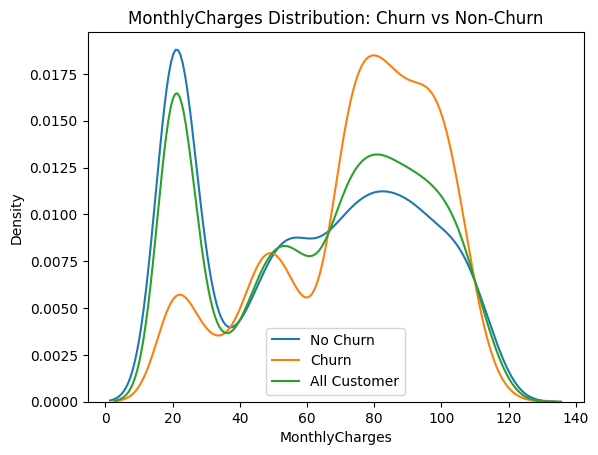

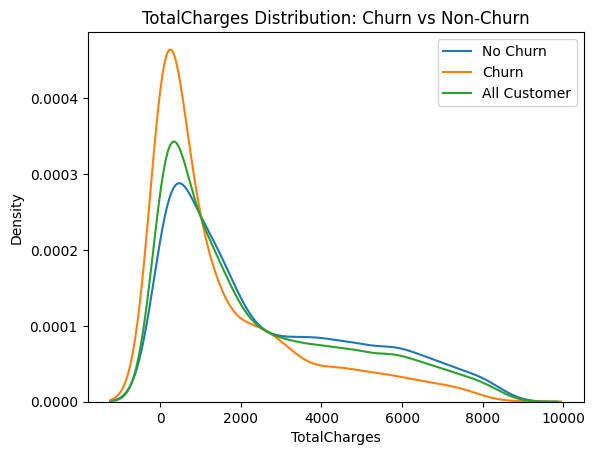

In [18]:
for feature in numeric_features:
    compare_distribution(df, feature)

#### Categorical Feature Distribution Comparison (Churn vs. Non-Churn)

In [19]:
def compare_categorical(df, column):
    ct = pd.crosstab(df[column], df["Churn"], normalize="columns")
    ct.plot(kind="bar")
    plt.title(f"{column} Distribution (Normalized by Churn)")
    plt.ylabel("Proportion")
    plt.show()

    return ct

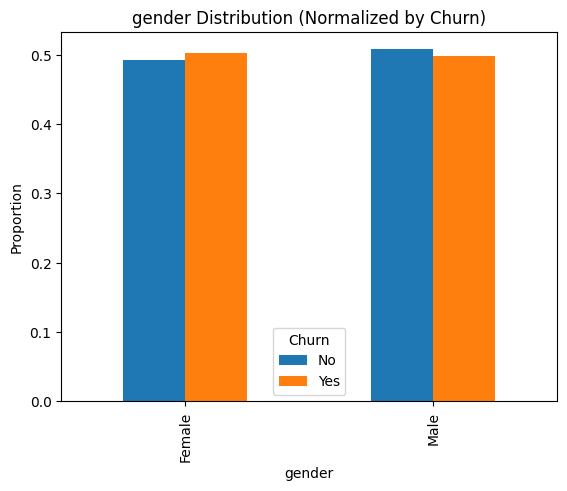

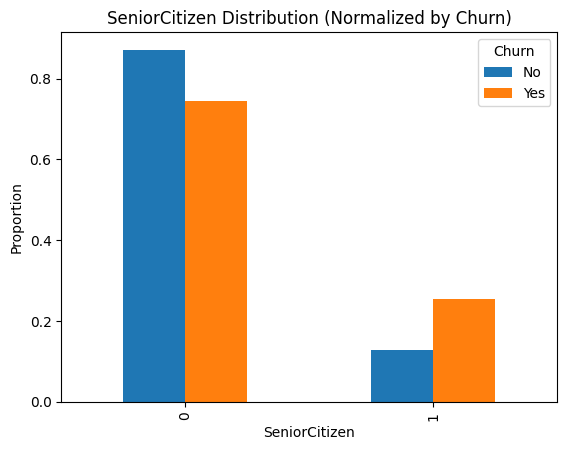

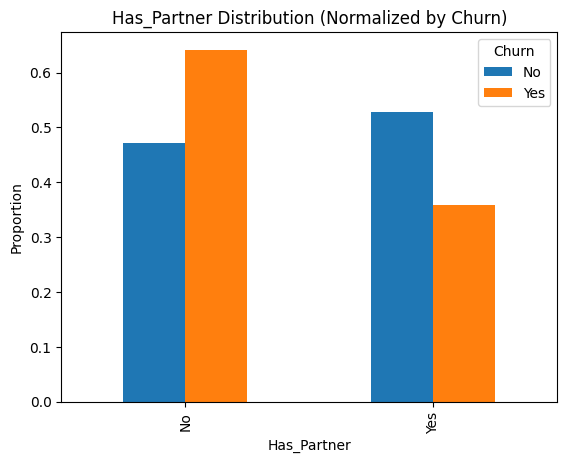

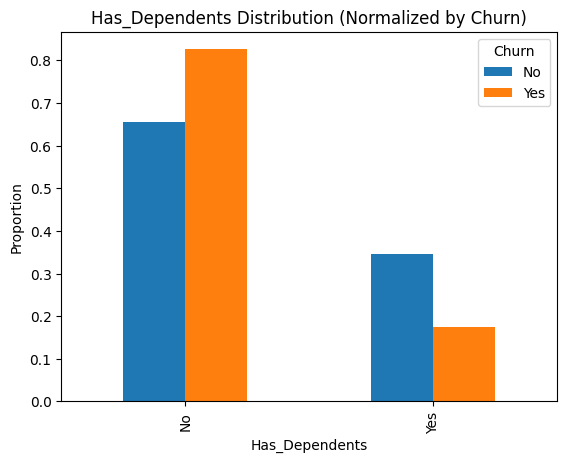

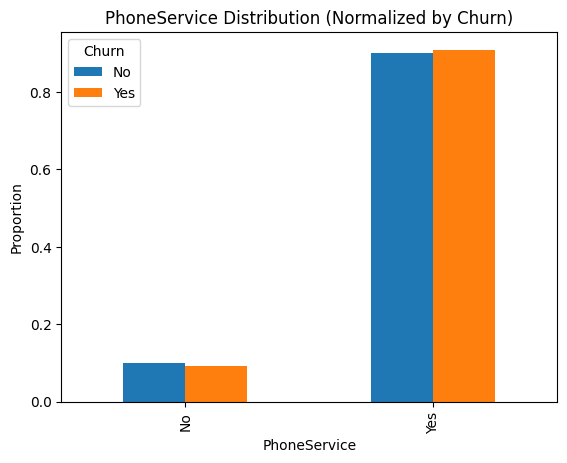

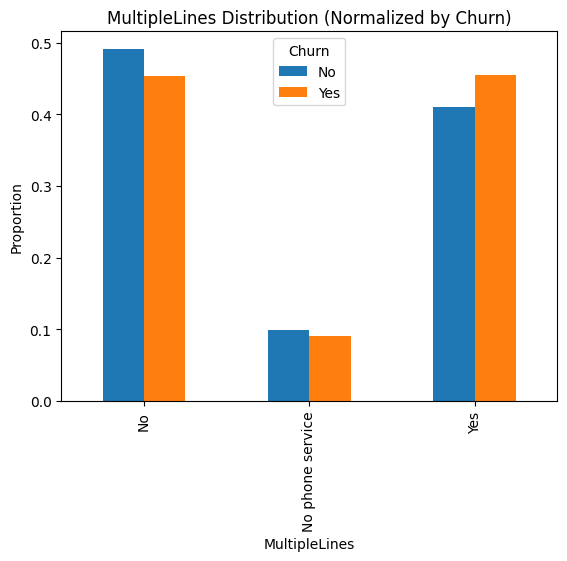

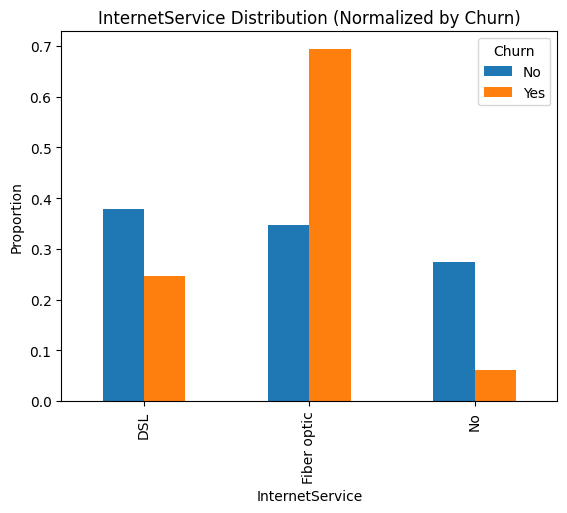

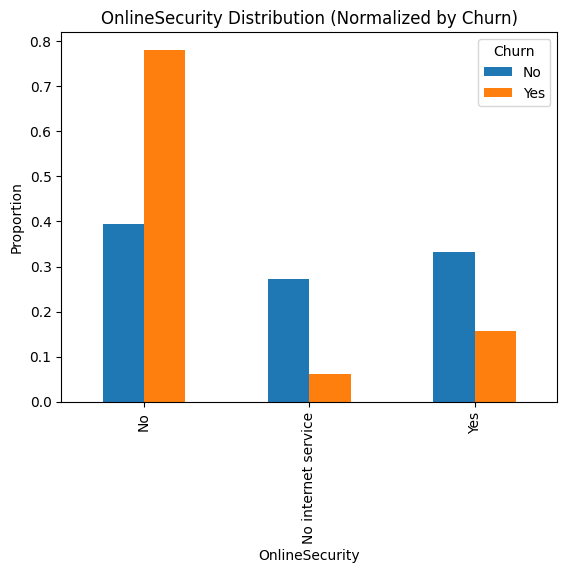

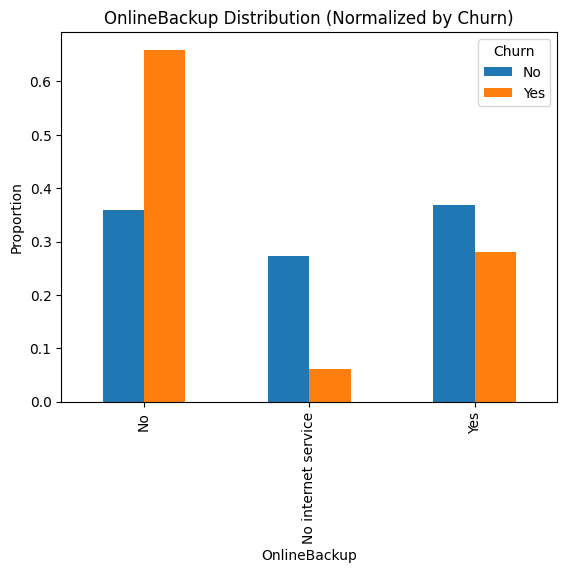

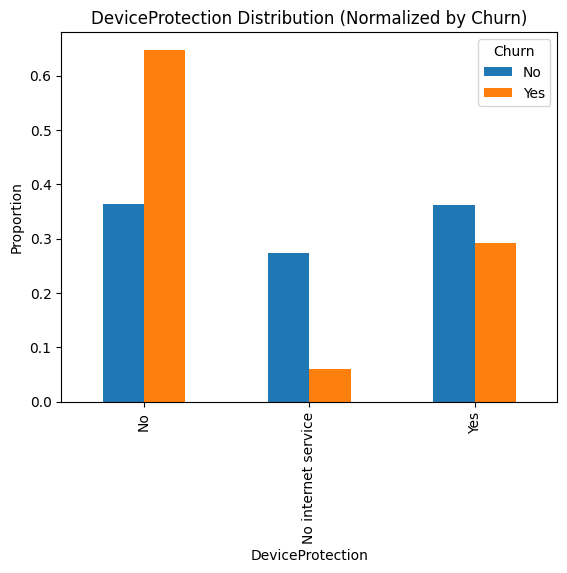

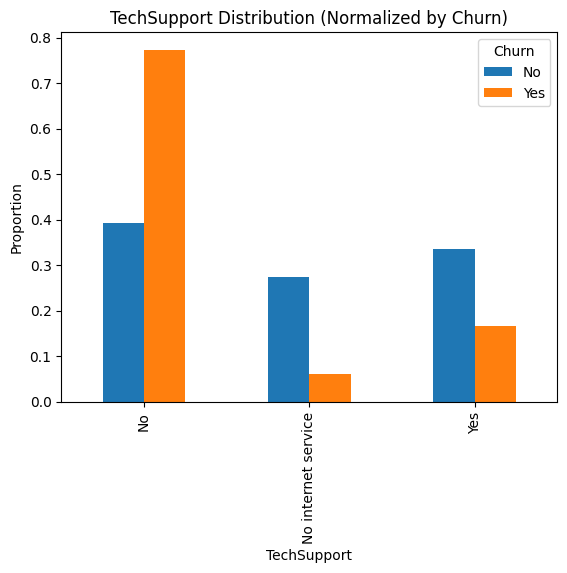

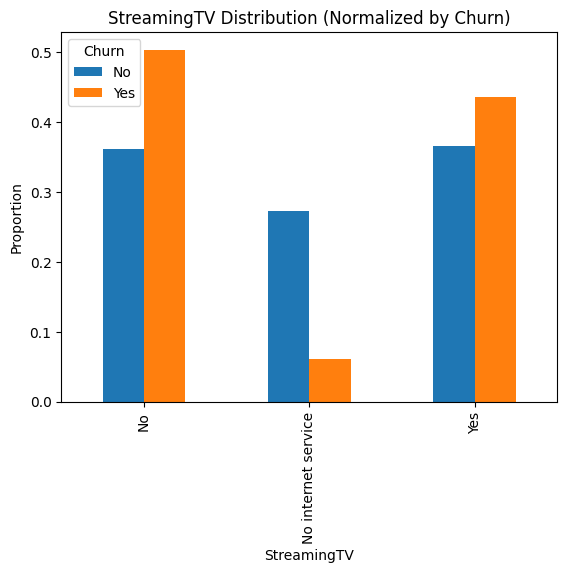

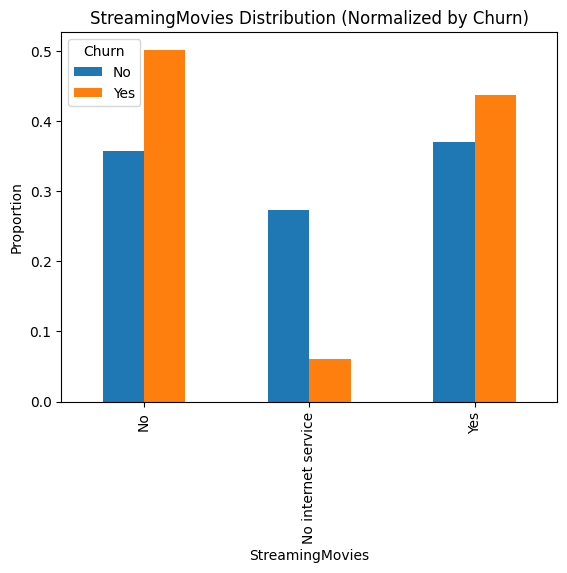

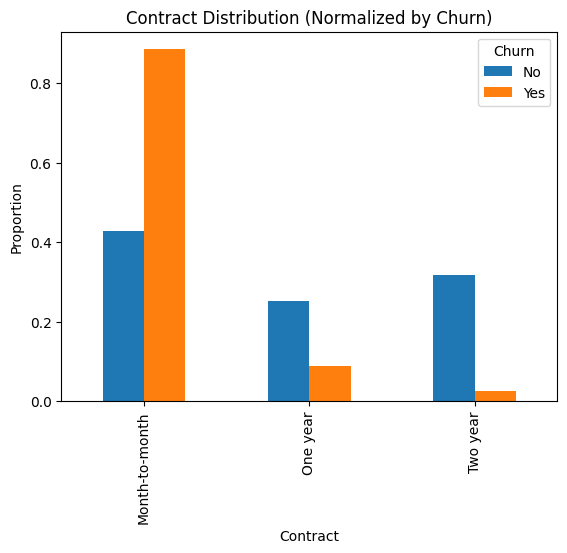

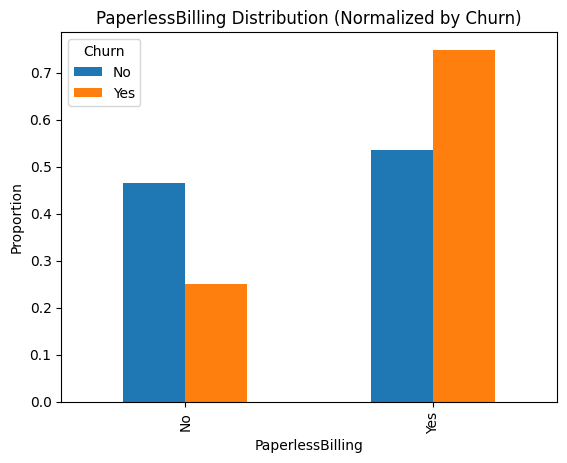

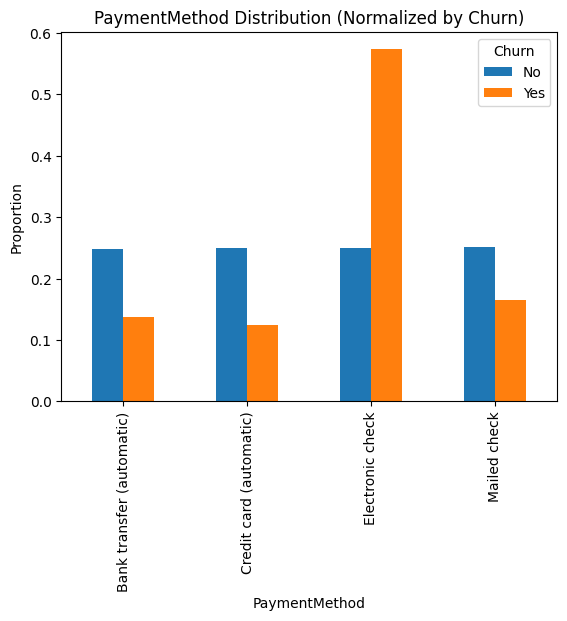

In [20]:
for feature in categorical_features:
    compare_categorical(df, feature)

#### Churn Rate by Categorical Feature

In [21]:
import matplotlib.pyplot as plt

def churn_rate_by_feature(df, column):
    rates = df.groupby(column, observed=True)["Churn_Flag"].mean().sort_values()

    ax = rates.plot(kind="bar")  # capture axis

    plt.title(f"Churn Rate by {column}")
    plt.ylabel("Churn Rate")

    # Annotate each bar
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.2%}",  # format as percentage
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom',
            xytext=(0, 3),
            textcoords='offset points'
        )

    plt.show()

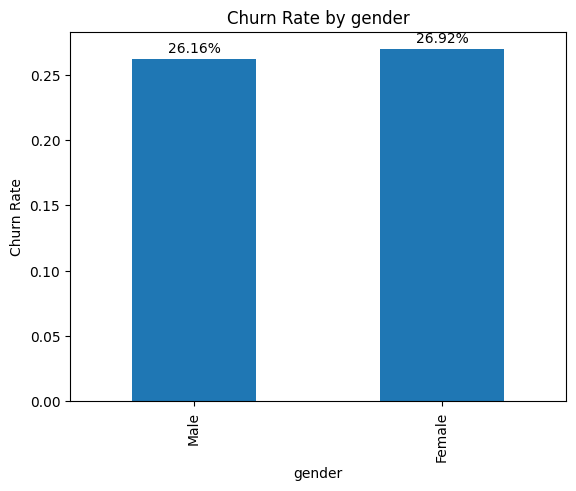

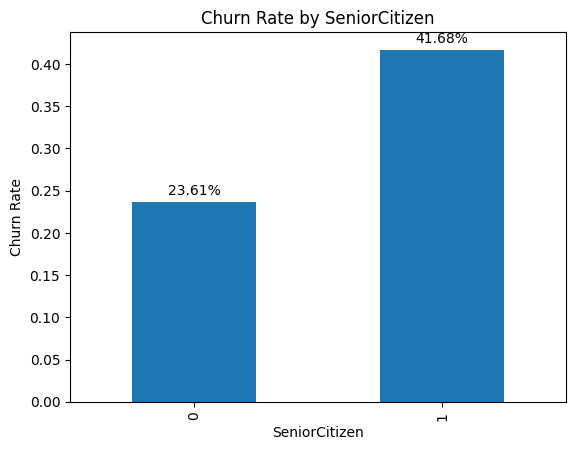

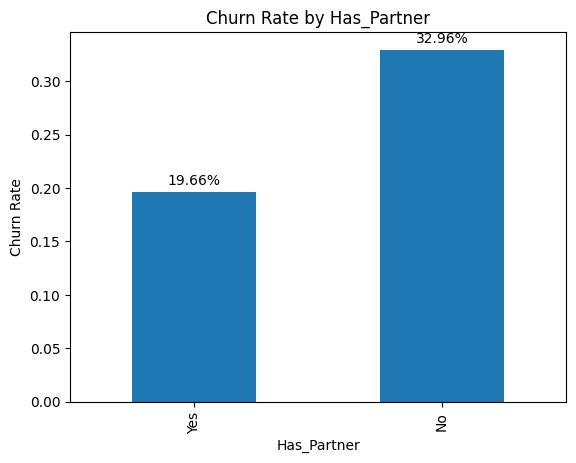

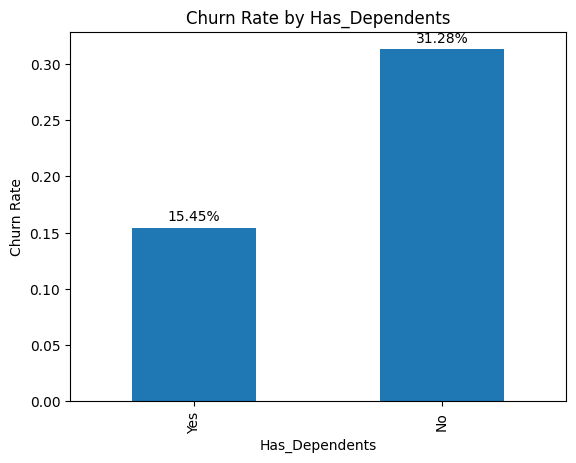

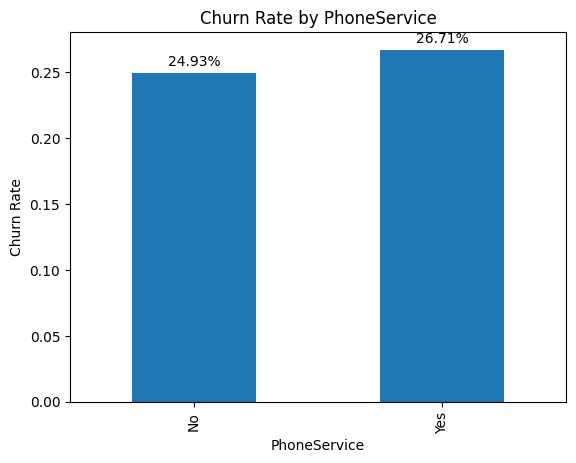

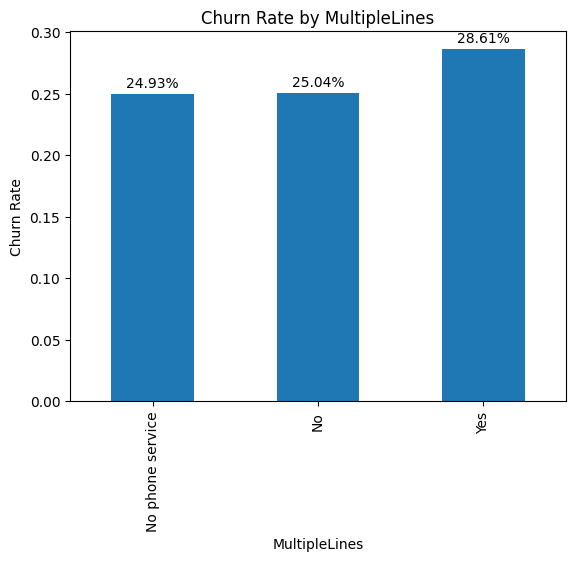

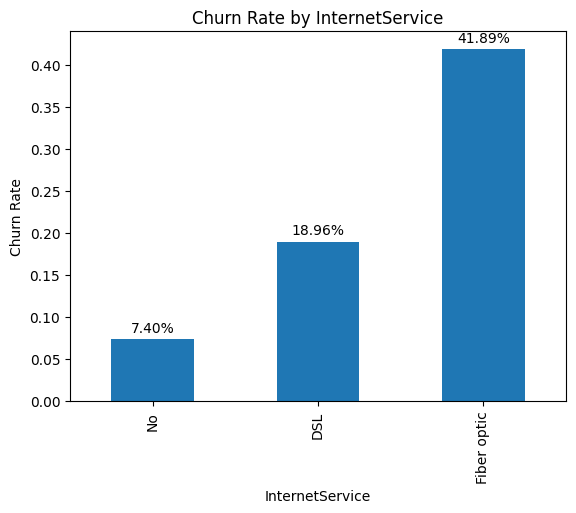

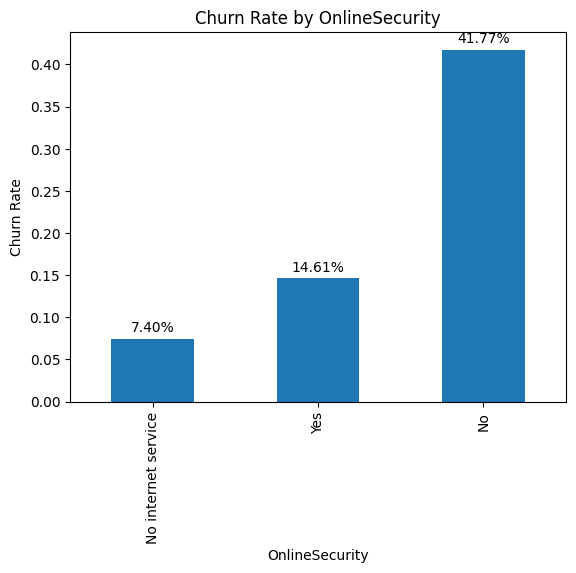

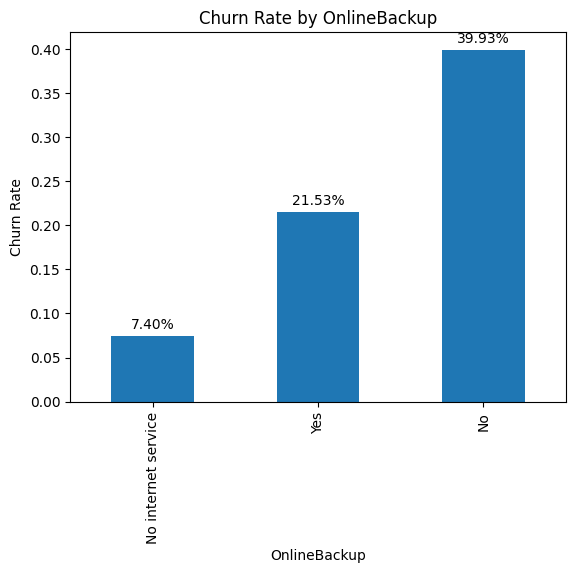

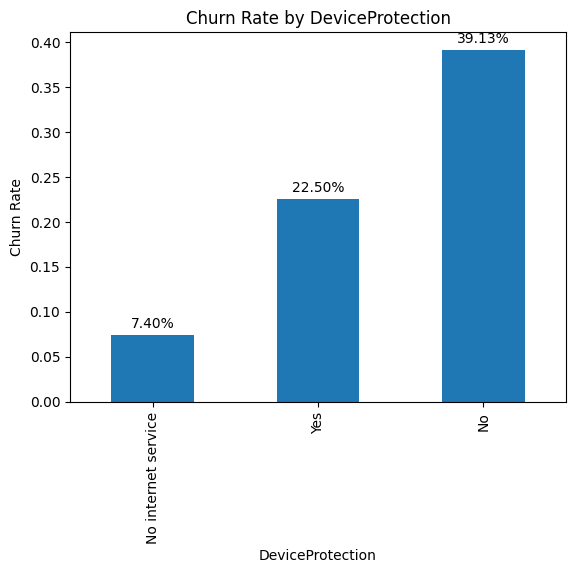

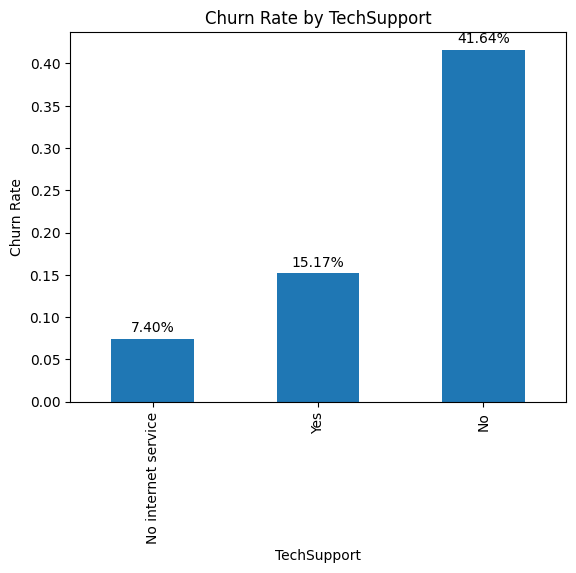

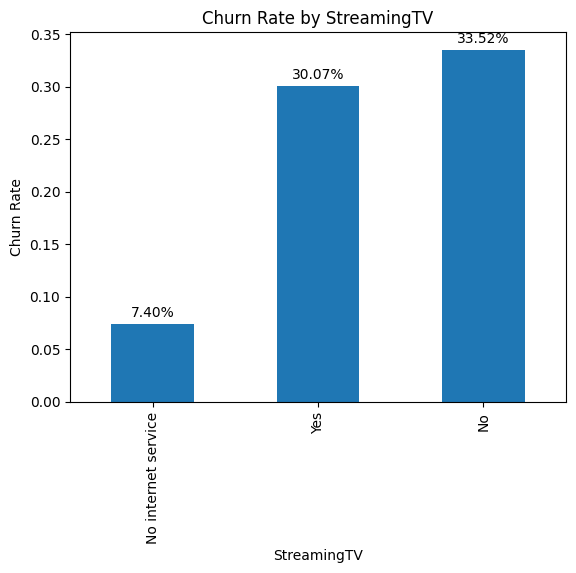

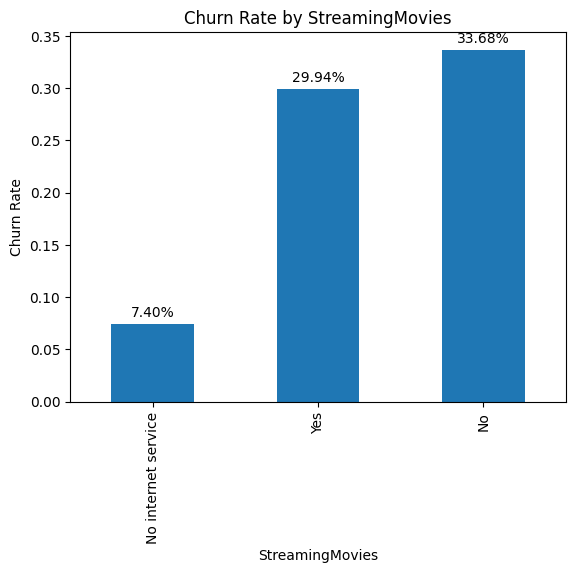

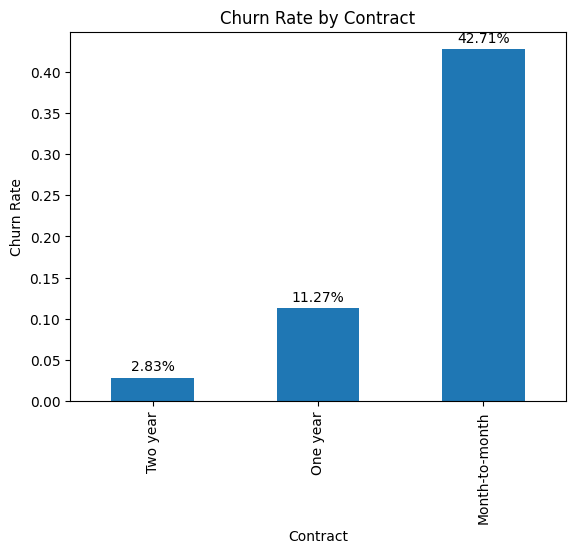

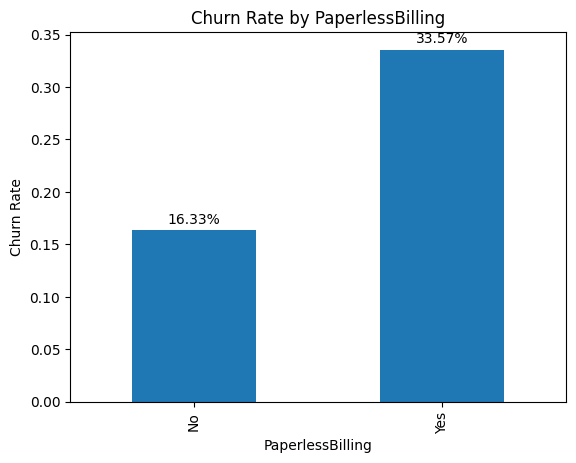

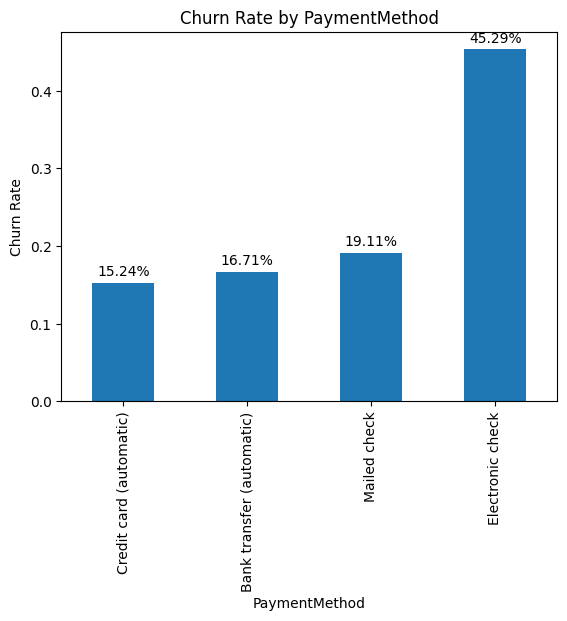

In [22]:
for feature in categorical_features:
    churn_rate_by_feature(df, feature)

#### Key Findings and Insights from EDA

1.  **Overall Churn Rate:** The dataset reveals an overall churn rate of **26.54%**, which is a significant proportion of customers leaving TelConnect.

2.  **Tenure and Charges:**
    *   **Shorter Tenure:** Churned customers overwhelmingly tend to have shorter account tenures, with the highest churn observed in the initial months of service. This suggests early engagement and retention strategies are crucial.
    *   **Higher Monthly Charges:** There's a positive correlation between Monthly Charges and churn. Customers with higher monthly bills are more likely to churn.
    *   **Lower Total Charges:** Churned customers generally have lower Total Charges, which is a direct consequence of their shorter tenure. This indicates that long-term, high-value customers are less likely to churn.

3.  **Contract Type:**
    *   **Month-to-month contracts** are a major churn driver, showing significantly higher churn rates compared to one-year and two-year contracts. Customers committed to longer contracts are much more loyal.

4.  **Internet Service:**
    *   **Fiber optic internet service** is associated with a much higher churn rate than DSL or no internet service. This might point to customer dissatisfaction with fiber optic performance, pricing, or service expectations.

5.  **Payment Method:**
    *   **Electronic check** is the payment method most frequently associated with churn.

6.  **Additional Services:**
    *   Customers who **do not subscribe to essential services** like Online Security, Online Backup, Device Protection, and Tech Support show higher churn rates. This suggests these services act as retention mechanisms.

7.  **Demographics and Preferences:**
    *   **Senior Citizens** have a slightly higher churn rate.
    *   Customers **without a partner or dependents** are more likely to churn.
    *   **Paperless Billing** users also show a higher tendency to churn.
    *   **Gender** does not appear to be a significant predictor of churn.

#### Insight-Driven Retention Strategies

Based on the key findings from our Exploratory Data Analysis, here are actionable strategies to address customer churn:

1.  **Address Early Churn (Shorter Tenure):**
    *   **Insight:** Customers with shorter account tenures exhibit significantly higher churn rates, especially in the initial months.
    *   **Strategy:** Implement a robust **onboarding program** for new customers. This could include personalized welcome calls, usage tips, and proactive check-ins during the first 3-6 months. Offer special incentives or discounts on services after 3 months of continuous service to encourage early commitment and reduce the likelihood of early departure.

2.  **Manage High Monthly Charges:**
    *   **Insight:** There is a positive correlation between higher monthly charges and churn. Customers with higher bills are more prone to leaving.
    *   **Strategy:** For high-risk customers with high monthly charges, offer a **discount or a loyalty bonus** that reduces their bill, especially if they commit to a longer contract. Analyze their usage to suggest more cost-effective plans or bundles that meet their needs without feeling overpriced.

3.  **Promote Longer-Term Contracts:**
    *   **Insight:** Month-to-month contracts are a major churn driver, while one-year and two-year contracts significantly reduce churn.
    *   **Strategy:** Actively incentivize customers on month-to-month plans to **upgrade to longer-term contracts** (1 or 2 years) by offering attractive discounts on monthly rates, free upgrades, or additional services. Clearly communicate the long-term value and savings associated with commitment.

4.  **Investigate Fiber Optic Service Satisfaction:**
    *   **Insight:** Fiber optic internet service is associated with a much higher churn rate compared to DSL or no internet service.
    *   **Strategy:** Conduct targeted surveys or focus groups with fiber optic customers to understand potential dissatisfaction points related to performance, pricing, or customer support. Proactively address these issues through service improvements, transparent communication, or competitive pricing adjustments.

5.  **Optimize Electronic Check Payment Experience:**
    *   **Insight:** Electronic check is the payment method most frequently associated with churn.
    *   **Strategy:** Investigate if there are friction points or issues with electronic check payments that lead to churn. Promote alternative, more stable payment methods (e.g., auto-pay with credit card/bank transfer) by offering small incentives or ensuring a seamless transition process.

6.  **Enhance Value with Additional Services:**
    *   **Insight:** Customers who do not subscribe to essential services like Online Security, Online Backup, Device Protection, and Tech Support show higher churn rates.
    *   **Strategy:** Position these services as **retention mechanisms**. Proactively offer trials, discounted bundles, or free additions of these additional services to at-risk customers, highlighting their value and benefits. This can increase stickiness and perceived value.

7.  **Tailor Offers for Specific Demographics:**
    *   **Insight:** Senior Citizens have a slightly higher churn rate, and customers without partners or dependents are more likely to churn. Paperless Billing users also show a higher tendency to churn.
    *   **Strategy:** Develop **targeted retention campaigns** for these segments. For Senior Citizens, simplify plans or offer dedicated support. For individuals without partners/dependents, focus on personalized benefits that appeal to single-person households. For Paperless Billing users, ensure digital communication is highly effective and address any potential issues that might lead to churn related to their billing preference.

## Data Preparation

#### Handling Missing Values in 'TotalCharges'
'TotalCharges' has 9 missing values. Given this small number, we will impute these values with the median. In scenarios with a larger proportion of missing data, a more thorough investigation and potentially a different imputation strategy would be necessary.

In [23]:
# Impute missing values in TotalCharges with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Verify no more missing values in TotalCharges
print(f"Missing values in TotalCharges after imputation: {df['TotalCharges'].isnull().sum()}")

Missing values in TotalCharges after imputation: 0


#### Feature Engineering

In [24]:
# Tenure buckets
df['tenure_group'] = pd.cut(df['account_tenure'], bins=[0, 6, 12, 24, 48, 100], labels=["0-6","6-12","12-24","24-48","48+"])

In [25]:
# Monthly Charges relative to total charges
df['avg_monthly_total_ratio'] = df['TotalCharges'] / (df['account_tenure'] + 1)  # avoid div by 0

In [26]:
# Services count / product penetration
service_cols = ["PhoneService","MultipleLines","InternetService","OnlineSecurity",
                "OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

df['num_services'] = df[service_cols].apply(lambda x: sum(x=='Yes'), axis=1)

In [27]:
# Has partner + dependents flag
df['family_flag'] = ((df['Has_Partner']=='Yes') | (df['Has_Dependents']=='Yes')).astype(int)

In [28]:
# Contract + PaperlessBilling interaction
df['month_to_month_paperless'] = ((df['Contract']=='Month-to-month') & (df['PaperlessBilling']=='Yes')).astype(int)

In [29]:
# Example: monthly charge per service
df['charge_per_service'] = df['MonthlyCharges'] / (df['num_services'] + 1)

In [30]:
df['engagement_score'] = df[['TechSupport','OnlineSecurity','DeviceProtection','StreamingTV','StreamingMovies']].apply(lambda x: sum(x=='Yes'), axis=1)

In [31]:
df['senior_family_flag'] = ((df['SeniorCitizen']==1) & (df['family_flag']==1)).astype(int)

In [32]:
# Identify numeric and categorical columns
X = df.drop(columns=["customerID", "Churn", "Churn_Flag"])
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

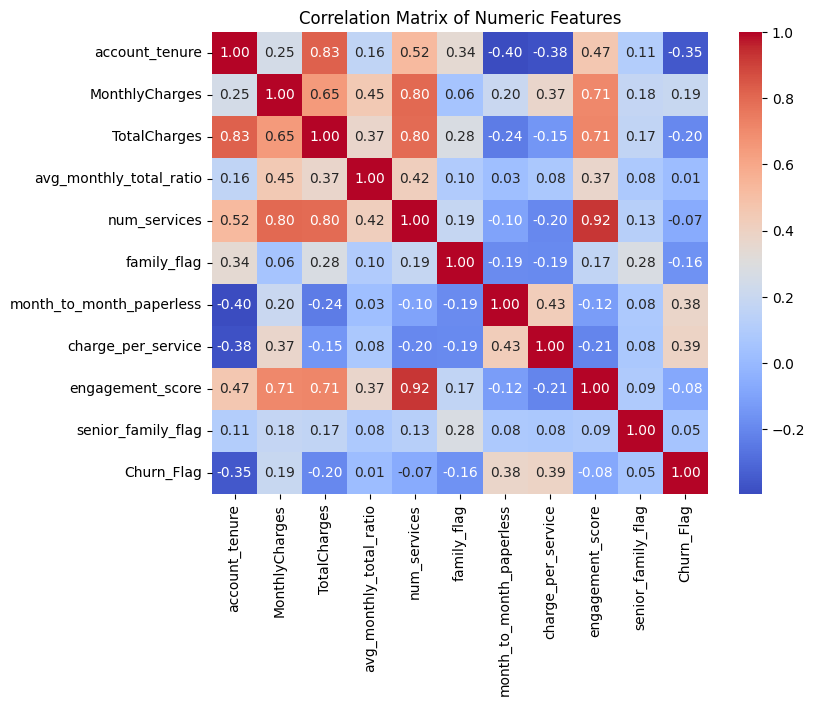

In [33]:
correlation_matrix = df[numeric_features + ["Churn_Flag"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Churn Prediction Modeling

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [35]:
# Features
X = df.drop(columns=["customerID", "Churn", "Churn_Flag"])
y = df["Churn_Flag"]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['category']).columns.tolist()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
X.columns

Index(['gender', 'SeniorCitizen', 'Has_Partner', 'Has_Dependents',
       'account_tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group',
       'avg_monthly_total_ratio', 'num_services', 'family_flag',
       'month_to_month_paperless', 'charge_per_service', 'engagement_score',
       'senior_family_flag'],
      dtype='object')

#### Hyperparameter Selection with Cross-Validation

In [37]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
# ----------------------------
# 5. Define models and hyperparameter grids
# ----------------------------

# Logistic Regression
logreg_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
logreg_param_grid = {
    'clf__C': [0.01, 0.1, 1, 5, 10],
    'clf__class_weight': [None, 'balanced', {0:1, 1:4}, {0:1, 1:5}, {0:1, 1:6}]
}

# Random Forest
rf_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])
rf_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [5, 10, 15, 20, None],
    'clf__class_weight': [None, 'balanced', {0:1, 1:4}, {0:1, 1:5}, {0:1, 1:6}]
}

# XGBoost
xgb_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])
xgb_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5, 10, 15],
    'clf__learning_rate': [0.01, 0.1],
    'clf__scale_pos_weight': [1, (y_train == 0).sum() / (y_train == 1).sum(), 4, 5, 6]
}

In [39]:

# ----------------------------
# 6. CV for hyperparameter tuning
# ----------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = 'f1'  # focus on churn F1 score

def tune_model(pipeline, param_grid, X_train, y_train):
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best params: {grid.best_params_}")
    return grid.best_estimator_

best_logreg = tune_model(logreg_pipeline, logreg_param_grid, X_train, y_train)
best_rf = tune_model(rf_pipeline, rf_param_grid, X_train, y_train)
best_xgb = tune_model(xgb_pipeline, xgb_param_grid, X_train, y_train)

# ----------------------------
# 7. Evaluate on test set
# ----------------------------
def evaluate_test(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    # Probabilities (for AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {model_name} Test Performance ===")
    print(classification_report(y_test, y_pred, digits=2))

    # AUC
    auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {auc:.3f}")

evaluate_test(best_logreg, X_test, y_test, "Logistic Regression")
evaluate_test(best_rf, X_test, y_test, "Random Forest")
evaluate_test(best_xgb, X_test, y_test, "XGBoost")

Best params: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}
Best params: {'clf__class_weight': {0: 1, 1: 6}, 'clf__max_depth': 10, 'clf__n_estimators': 100}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:10:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__scale_pos_weight': np.float64(2.768561872909699)}

=== Logistic Regression Test Performance ===
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.843

=== Random Forest Test Performance ===
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC: 0.838

=== XGBoost Test Performance ===
              precision    recall  f1-score   suppor

#### Selecting XGBoost as the Deployed Model
This model has achieved the highest AUC (0.845) among the evaluated models, indicating its superior ability to distinguish between churning and non-churning customers. It also demonstrated a strong recall of 0.80 for the churn class, ensuring that a high percentage of actual churners are identified, which is crucial for retention efforts. Furthermore, it maintained a balanced accuracy, demonstrating robust performance across both classes.

XGBoost is also highly effective due to its ability to intrinsically handle both numerical and categorical data, its robustness to outliers, and its powerful ensemble learning approach that often leads to high predictive accuracy. Its capacity to model complex non-linear relationships makes it a suitable choice for this churn prediction task.

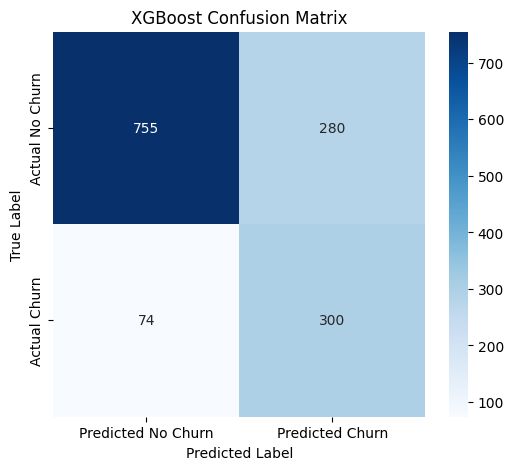

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions from the best XGBoost model on the test set
y_pred_xgb = best_xgb.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Confusion Matrix')
plt.show()


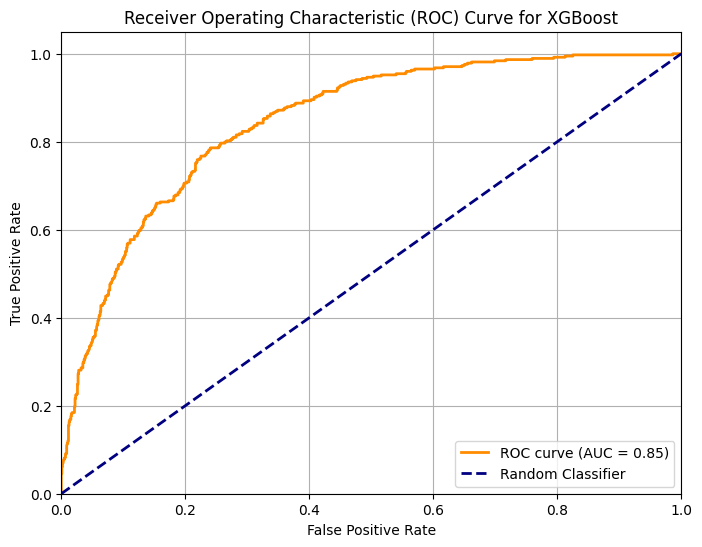

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (churn=1) from the best XGBoost model
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# Calculate AUC score
auc_score_xgb = roc_auc_score(y_test, y_prob_xgb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### XGBoost Built-in Feature Importance

In [42]:
import pandas as pd
import numpy as np

# Get the best XGBoost model
xgb_model = best_xgb.named_steps['clf']
preprocessor = best_xgb.named_steps['preproc']

# Get feature names after preprocessing
def get_feature_names(column_transformer):
    output_features = []
    for name, preproc_step, features in column_transformer.transformers_:
        if preproc_step == 'drop' or preproc_step == 'passthrough':
            continue
        if hasattr(preproc_step, 'get_feature_names_out'):
            if isinstance(features, str):
                features = [features]
            output_features.extend(preproc_step.get_feature_names_out(features))
        else:
            if isinstance(features, str):
                features = [features]
            output_features.extend(features)
    return output_features

feature_names = get_feature_names(preprocessor)

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("XGBoost Feature Importances (sorted):")
# Format the 'Importance' column as percentage before printing
feature_importance_df['Importance'] = feature_importance_df['Importance'].apply(lambda x: f"{x:.2%}")
print(feature_importance_df.to_string(index=False))

XGBoost Feature Importances (sorted):
                                Feature Importance
                Contract_Month-to-month     50.81%
            InternetService_Fiber optic      5.61%
               month_to_month_paperless      4.68%
                      OnlineSecurity_No      4.46%
         PaymentMethod_Electronic check      3.14%
                     charge_per_service      3.01%
                       tenure_group_0-6      2.45%
                      Contract_Two year      2.12%
                    StreamingMovies_Yes      2.05%
                     StreamingMovies_No      2.00%
                         TechSupport_No      1.80%
                         StreamingTV_No      1.75%
                    InternetService_DSL      1.75%
                      Contract_One year      1.55%
                         account_tenure      1.38%
                        StreamingTV_Yes      0.87%
                       engagement_score      0.84%
                        OnlineBackup_No     

#### SHAP (SHapley Additive exPlanations) for Model Interpretability

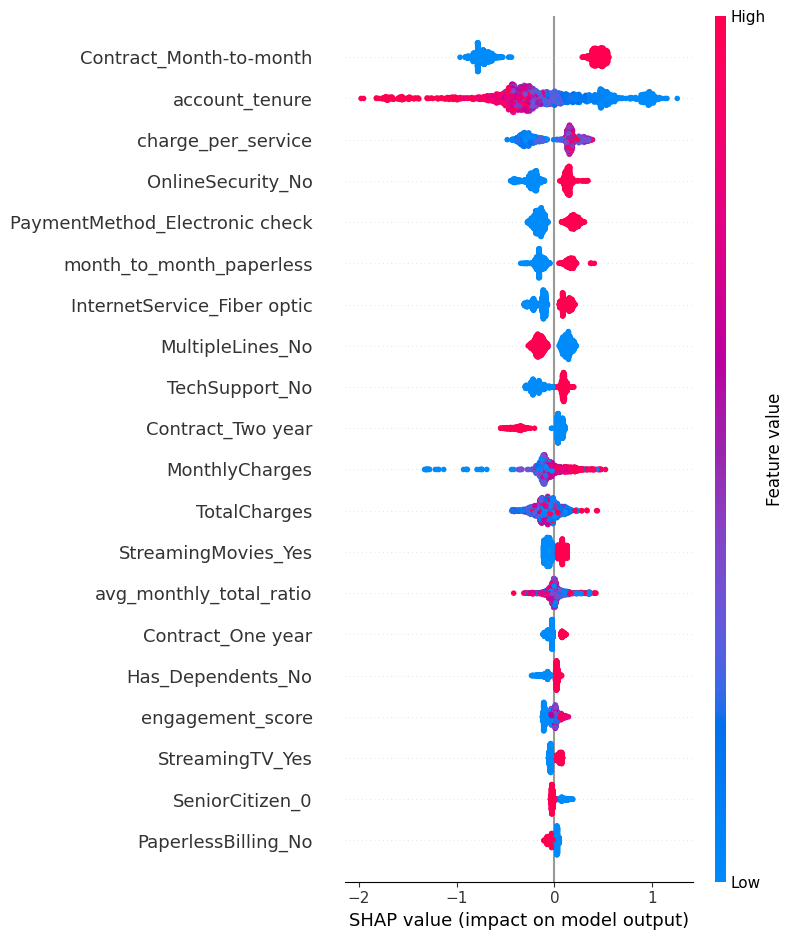

In [43]:
import shap

# Shap
X_test_transformed = preprocessor.transform(X_test)

# Initialize a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(best_xgb.named_steps['clf'])

shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [44]:
import pandas as pd
import numpy as np

# 1. Calculate Mean SHAP and Mean Absolute SHAP
# shap_values is (n_samples, n_features)
mean_shap = shap_values.mean(axis=0)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# 2. Determine Direction correctly:
# We check the correlation between the feature's actual value and its SHAP value.
# Positive correlation = Higher feature value increases churn risk.
# Negative correlation = Higher feature value reduces churn risk.
directions = []
correlation_list = []
for i in range(X_test_transformed.shape[1]):
    # Calculate correlation between the feature values and the SHAP values
    correlation = np.corrcoef(X_test_transformed[:, i], shap_values[:, i])[0, 1]

    if correlation > 0:
        directions.append("▲ increases churn risk")
        correlation_list.append(correlation)
    else:
        directions.append("▼ reduces churn risk")
        correlation_list.append(correlation)

# 3. Create the Summary DataFrame
mean_shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap,
    'direction': directions,
    'correlation': correlation_list
})

# 4. Sort by importance and display
mean_shap_df = mean_shap_df.sort_values('mean_abs_shap', ascending=False).head(12)

print("--- SHAP Feature Impact Summary ---")
print(mean_shap_df[['feature', 'mean_abs_shap', 'direction', 'correlation']].to_string(index=False))

--- SHAP Feature Impact Summary ---
                       feature  mean_abs_shap              direction  correlation
       Contract_Month-to-month       0.582928 ▲ increases churn risk     0.994400
                account_tenure       0.467221   ▼ reduces churn risk    -0.874502
            charge_per_service       0.225191 ▲ increases churn risk     0.681995
             OnlineSecurity_No       0.182526 ▲ increases churn risk     0.961020
PaymentMethod_Electronic check       0.170100 ▲ increases churn risk     0.967787
      month_to_month_paperless       0.152146 ▲ increases churn risk     0.967555
   InternetService_Fiber optic       0.146745 ▲ increases churn risk     0.929048
              MultipleLines_No       0.145348   ▼ reduces churn risk    -0.966812
                TechSupport_No       0.139145 ▲ increases churn risk     0.954359
             Contract_Two year       0.135648   ▼ reduces churn risk    -0.982887
                MonthlyCharges       0.127524 ▲ increases chur

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Business Simulation: Retention Strategy Impact

In [45]:
# ============================================================
# Two-intervention model: proactive outreach + reactive voucher
# ============================================================


# ── 1: Assumptions ─────────────────────────────────────────────────

"""
ASSUMPTIONS
----------------------------------------------------------------
FROM DOCUMENT:
  - Voucher cost to TelConnect = $30 per voucher issued
  - Reactive acceptance rate   = 40% of customers who call to cancel

ASSUMPTIONS:
  - CLV proxy = MonthlyCharges × 6
      Rationale: no actual CLV data provided. We use a 6-month horizon as
      a conservative estimate, covering at least twice the voucher period.
      In practice, would request survival-curve CLV estimates.

  - Proactive outreach acceptance rate = 25%
      Rationale: proactive campaigns target customers who have NOT
      yet decided to leave. The offer is unsolicited, so acceptance
      is lower than reactive saves (where the customer is actively
      trying to cancel). Industry telecom benchmarks suggest 10–25%
      for proactive retention campaigns. Using 25% as mid-range.
      THIS IS THE KEY UNCERTAINTY — flagged as primary data gap;
      an A/B test is the first recommended next step.

  - Proactive outreach cost = $18 per customer contacted
      Covers targeted personalised campaign (email, service upgrade
      offer, or retention call). No voucher is issued proactively —
      the $30 voucher is reserved for customers who call to cancel.

  - False positive cost (proactive tier):
      Customers targeted proactively who would NOT have churned
      still incur the $18 outreach cost. No voucher cost unless
      they later call to cancel (treated as background noise).

  - Reactive voucher still applies to ALL customers who call to
      cancel, regardless of whether they were proactively targeted.
      The two interventions are additive for Tier 1 customers.
----------------------------------------------------------------
"""

VOUCHER_COST         = 30    # $ — from document
REACTIVE_ACCEPT      = 0.40  # from document
PROACTIVE_ACCEPT     = 0.25  # assumption — 25%, see rationale above
PROACTIVE_COST       = 18    # $ per customer contacted — assumption
CLV_MONTHS           = 6     # assumption — 6-month retention horizon

In [46]:
# ── 2: Core profit simulation (single intervention sweep) ───────────
# This sweeps the proactive outreach threshold.
# Customers above the threshold get proactive outreach ($18).
# All actual churners who weren't retained proactively are assumed
# to call and get the reactive voucher offer ($30, 40% accept).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

y_prob = best_xgb.predict_proba(X_test)[:, 1]
y_true = y_test.values
clv    = X_test["MonthlyCharges"].values * CLV_MONTHS

n_churners = (y_true == 1).sum()
n_total    = len(y_true)

thresholds = np.linspace(0.01, 0.80, 200)
results = []

for t in thresholds:
    proactive_mask = (y_prob >= t)                       # who gets $18 outreach
    tp_proactive   = proactive_mask & (y_true == 1)      # targeted + actual churner
    fp_proactive   = proactive_mask & (y_true == 0)      # targeted + would have stayed

    # ── Proactive intervention ────────────────────────────────────────
    # Revenue: churners who accept the proactive offer (25%)
    proactive_revenue = (clv[tp_proactive] * PROACTIVE_ACCEPT).sum()
    # Cost: everyone we contact pays $18
    proactive_cost    = proactive_mask.sum() * PROACTIVE_COST

    # ── Reactive voucher (backstop) ───────────────────────────────────
    # Churners NOT saved proactively are assumed to call to cancel.
    # 40% of those accept the reactive $30 voucher.
    # This applies to both: (a) churners we didn't target at all,
    # and (b) churners we targeted proactively but who didn't accept.

    # Simplify: expected number not saved = TP × (1 - proactive_accept) + FN
    n_tp        = tp_proactive.sum()
    n_fn        = (y_true == 1).sum() - n_tp
    n_reactive  = (n_tp * (1 - PROACTIVE_ACCEPT)) + n_fn   # expected churners calling

    # Average CLV for reactive pool (mix of TP remainder + all FN)
    # Use overall churner average CLV as approximation
    avg_clv_churner = clv[y_true == 1].mean()
    reactive_revenue = n_reactive * REACTIVE_ACCEPT * avg_clv_churner
    reactive_cost    = n_reactive * REACTIVE_ACCEPT * VOUCHER_COST

    # ── Net ───────────────────────────────────────────────────────────
    total_revenue  = proactive_revenue + reactive_revenue
    total_cost     = proactive_cost    + reactive_cost
    net_profit     = total_revenue     - total_cost

    recall    = n_tp / n_churners if n_churners > 0 else 0
    precision = n_tp / proactive_mask.sum() if proactive_mask.sum() > 0 else 0

    results.append({
        "threshold":          t,
        "net_profit":         net_profit,
        "proactive_revenue":  proactive_revenue,
        "reactive_revenue":   reactive_revenue,
        "total_revenue":      total_revenue,
        "proactive_cost":     proactive_cost,
        "reactive_cost":      reactive_cost,
        "total_cost":         total_cost,
        "n_proactive":        int(proactive_mask.sum()),
        "recall":             recall,
        "precision":          precision,
    })

sim = pd.DataFrame(results)
best_idx = sim["net_profit"].idxmax()
best_row = sim.loc[best_idx]

print("=" * 62)
print(f"  Customer population          : {len(y_true)}")
print(f"  Optimal proactive threshold  : {best_row['threshold']:.3f}")
print(f"  Net profit  (test set)       : ${best_row['net_profit']:>10,.0f}")
print(f"  — Proactive revenue          : ${best_row['proactive_revenue']:>10,.0f}")
print(f"  — Reactive revenue           : ${best_row['reactive_revenue']:>10,.0f}")
print(f"  — Proactive cost ($18 × n)   : ${best_row['proactive_cost']:>10,.0f}")
print(f"  — Reactive cost  ($30 × n)   : ${best_row['reactive_cost']:>10,.0f}")
print(f"  Customers contacted proact.  : {int(best_row['n_proactive']):>10,}")
print(f"  Recall (churners targeted)   : {best_row['recall']:>10.1%}")
print(f"  Precision                    : {best_row['precision']:>10.1%}")
print("=" * 62)

  Customer population          : 1409
  Optimal proactive threshold  : 0.562
  Net profit  (test set)       : $    71,922
  — Proactive revenue          : $    32,142
  — Reactive revenue           : $    52,785
  — Proactive cost ($18 × n)   : $     9,378
  — Reactive cost  ($30 × n)   : $     3,627
  Customers contacted proact.  :        521
  Recall (churners targeted)   :      76.7%
  Precision                    :      55.1%


In [47]:
# ── 5: Current vs optimized comparison ──────────────────────────────

Customer_scale_factor = len(y) / len(y_true)  # scale test set results to population

# ----------------------------
# Reactive only (current state)
# ----------------------------
def reactive_only_profit(y_true, clv):
    n_churners_test = (y_true == 1).sum()
    n_react_accept = n_churners_test * REACTIVE_ACCEPT
    baseline_revenue = n_react_accept * clv[y_true == 1].mean()
    reactive_cost = n_react_accept * VOUCHER_COST
    baseline_profit = baseline_revenue - reactive_cost
    # Remaining churners
    still_churn = n_churners_test - n_react_accept
    return (
        baseline_profit * Customer_scale_factor,
        baseline_revenue * Customer_scale_factor,
        0,                        # proactive cost
        reactive_cost * Customer_scale_factor,
        reactive_cost * Customer_scale_factor, # total cost
        0,                        # proactively targeted
        0,                        # proactive accepted
        n_react_accept * Customer_scale_factor,
        n_churners_test * Customer_scale_factor,
        still_churn * Customer_scale_factor
    )

# ----------------------------
# Optimized: proactive + reactive backstop
# ----------------------------
def two_intervention_profit(y_true, y_prob, clv, pro_threshold):
    pm = (y_prob >= pro_threshold)
    tp = pm & (y_true == 1)
    n_tp_v = tp.sum()
    n_fn_v = (y_true == 1).sum() - n_tp_v

    # Revenue & cost for proactive
    pro_rev = (clv[tp] * PROACTIVE_ACCEPT).sum()
    pro_cost = pm.sum() * PROACTIVE_COST

    # Reactive offer for those who still churn
    n_react = n_tp_v * (1 - PROACTIVE_ACCEPT) + n_fn_v
    react_rev = n_react * REACTIVE_ACCEPT * clv[y_true == 1].mean()
    react_cost = n_react * REACTIVE_ACCEPT * VOUCHER_COST

    total_rev = pro_rev + react_rev
    total_cost = pro_cost + react_cost
    total_profit = total_rev - total_cost

    # Accepted counts
    n_pro_accept = tp.sum() * PROACTIVE_ACCEPT
    n_react_accept = n_react * REACTIVE_ACCEPT
    still_churn = n_react - n_react_accept

    return (
        total_profit * Customer_scale_factor,
        total_rev * Customer_scale_factor,
        pro_cost * Customer_scale_factor,
        react_cost * Customer_scale_factor,
        total_cost * Customer_scale_factor,
        int(pm.sum() * Customer_scale_factor),       # proactively targeted
        int(n_pro_accept * Customer_scale_factor),   # accepted proactive
        int(n_react_accept * Customer_scale_factor), # accepted reactive
        (n_tp_v + n_fn_v) * Customer_scale_factor,   # total churners intended
        int(still_churn * Customer_scale_factor)     # still churn
    )

# ----------------------------
# Compute metrics
# ----------------------------
cur_profit, cur_rev, cur_pro_cost, cur_react_cost, cur_total_cost, \
cur_n_pro, cur_n_pro_accept, cur_n_react_accept, cur_total_churners, cur_still_churn = reactive_only_profit(y_true, clv)

opt_profit, opt_rev, opt_pro_cost, opt_react_cost, opt_total_cost, \
opt_n_pro, opt_n_pro_accept, opt_n_react_accept, opt_total_churners, opt_still_churn = two_intervention_profit(
    y_true, y_prob, clv, pro_threshold=best_row["threshold"])

# ----------------------------
# Comparison table
# ----------------------------
comparison = pd.DataFrame({
    "Metric": [
        "Net profit",
        "Total revenue",
        "Proactive cost",
        "Reactive cost",
        "Total cost",
        "Customers proactively targeted",
        "Customers accepted proactive offer",
        "Customers accepted reactive offer",
        "Total churners (intended)",
        "Customers still churn"
    ],
    "Current (reactive only)": [
        f"${cur_profit:,.0f}",
        f"${cur_rev:,.0f}",
        f"${cur_pro_cost:,.0f}",
        f"${cur_react_cost:,.0f}",
        f"${cur_total_cost:,.0f}",
        f"{cur_n_pro:,}",
        f"{cur_n_pro_accept:,.0f}",
        f"{cur_n_react_accept:,.0f}",
        f"{cur_total_churners:,.0f}",
        f"{cur_still_churn:,.0f}"
    ],
    f"Optimized (t={best_row['threshold']:.2f})": [
        f"${opt_profit:,.0f}",
        f"${opt_rev:,.0f}",
        f"${opt_pro_cost:,.0f}",
        f"${opt_react_cost:,.0f}",
        f"${opt_total_cost:,.0f}",
        f"{opt_n_pro:,}",
        f"{opt_n_pro_accept:,.0f}",
        f"{opt_n_react_accept:,.0f}",
        f"{opt_total_churners:,.0f}",
        f"{opt_still_churn:,.0f}"
    ]
})

# ----------------------------
# Display
# ----------------------------
print(f"\n── Current vs optimized retention strategy (Customer Population of {len(y)}) ─────────────────────────\n")
print(comparison.to_string(index=False))
print("\nAssumptions: CLV = MonthlyCharges × 6  |  reactive accept = 40%  |")
print(f"proactive accept = {PROACTIVE_ACCEPT:.0%} (key uncertainty)  |  outreach = $18  |  voucher = $30")


── Current vs optimized retention strategy (Customer Population of 7043) ─────────────────────────

                            Metric Current (reactive only) Optimized (t=0.56)
                        Net profit                $304,052           $359,508
                     Total revenue                $326,486           $424,515
                    Proactive cost                      $0            $46,877
                     Reactive cost                 $22,434            $18,130
                        Total cost                 $22,434            $65,007
    Customers proactively targeted                       0              2,604
Customers accepted proactive offer                       0                358
 Customers accepted reactive offer                     748                604
         Total churners (intended)                   1,869              1,869
             Customers still churn                   1,122                906

Assumptions: CLV = MonthlyCharges × 6  |

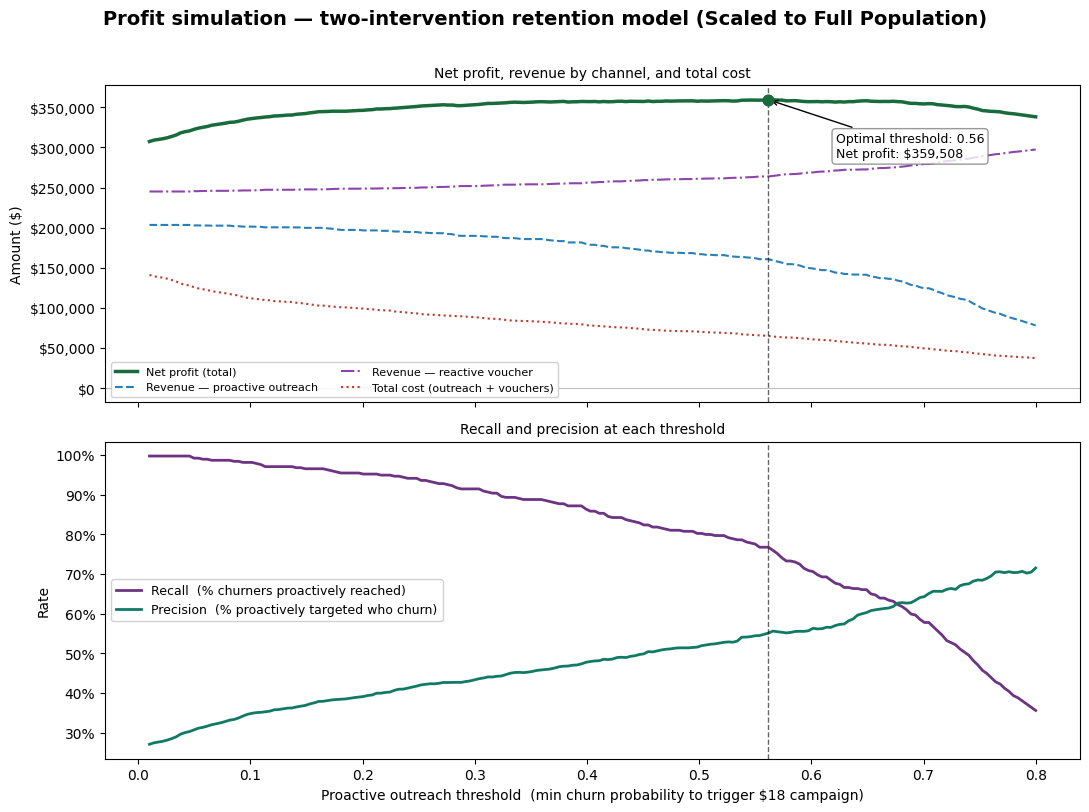

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Scale the simulation results to the full customer population
sim_scaled = sim.copy()
sim_scaled['net_profit'] = sim_scaled['net_profit'] * Customer_scale_factor
sim_scaled['proactive_revenue'] = sim_scaled['proactive_revenue'] * Customer_scale_factor
sim_scaled['reactive_revenue'] = sim_scaled['reactive_revenue'] * Customer_scale_factor
sim_scaled['total_cost'] = sim_scaled['total_cost'] * Customer_scale_factor

# Update best_row with scaled values for annotation
best_row_scaled = sim_scaled.loc[sim_scaled['net_profit'].idxmax()]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle("Profit simulation — two-intervention retention model (Scaled to Full Population)",
             fontsize=14, fontweight="bold", y=1.01)

# — Top: revenue stack and cost —
ax = axes[0]
ax.plot(sim_scaled["threshold"], sim_scaled["net_profit"],
        color="#1a6b3c", lw=2.5, label="Net profit (total)")
ax.plot(sim_scaled["threshold"], sim_scaled["proactive_revenue"],
        color="#2980b9", lw=1.5, ls="--", label="Revenue — proactive outreach")
ax.plot(sim_scaled["threshold"], sim_scaled["reactive_revenue"],
        color="#8e44ad", lw=1.5, ls="-.", label="Revenue — reactive voucher")
ax.plot(sim_scaled["threshold"], sim_scaled["total_cost"],
        color="#c0392b", lw=1.5, ls=":", label="Total cost (outreach + vouchers)")

ax.axvline(best_row_scaled["threshold"], color="black", lw=1, ls="--", alpha=0.6)
ax.scatter([best_row_scaled["threshold"]], [best_row_scaled["net_profit"]],
           color="#1a6b3c", zorder=5, s=60)
ax.annotate(
    f"Optimal threshold: {best_row_scaled['threshold']:.2f}\nNet profit: ${best_row_scaled['net_profit']:,.0f}",
    xy=(best_row_scaled["threshold"], best_row_scaled["net_profit"]),
    xytext=(best_row_scaled["threshold"] + 0.06, best_row_scaled["net_profit"] * 0.80),
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
    fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
)
ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_ylabel("Amount ($)")
ax.legend(framealpha=0.9, fontsize=8, ncol=2)
ax.set_title("Net profit, revenue by channel, and total cost", fontsize=10)

# — Bottom: recall & precision —
ax2 = axes[1]
ax2.plot(sim_scaled["threshold"], sim_scaled["recall"],
         color="#6c3483", lw=2, label="Recall  (% churners proactively reached)")
ax2.plot(sim_scaled["threshold"], sim_scaled["precision"],
         color="#117a65", lw=2, label="Precision  (% proactively targeted who churn)")
ax2.axvline(best_row_scaled["threshold"], color="black", lw=1, ls="--", alpha=0.6)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.set_ylabel("Rate")
ax2.set_xlabel("Proactive outreach threshold  (min churn probability to trigger $18 campaign)")
ax2.legend(framealpha=0.9, fontsize=9)
ax2.set_title("Recall and precision at each threshold", fontsize=10)

plt.tight_layout()
plt.show()

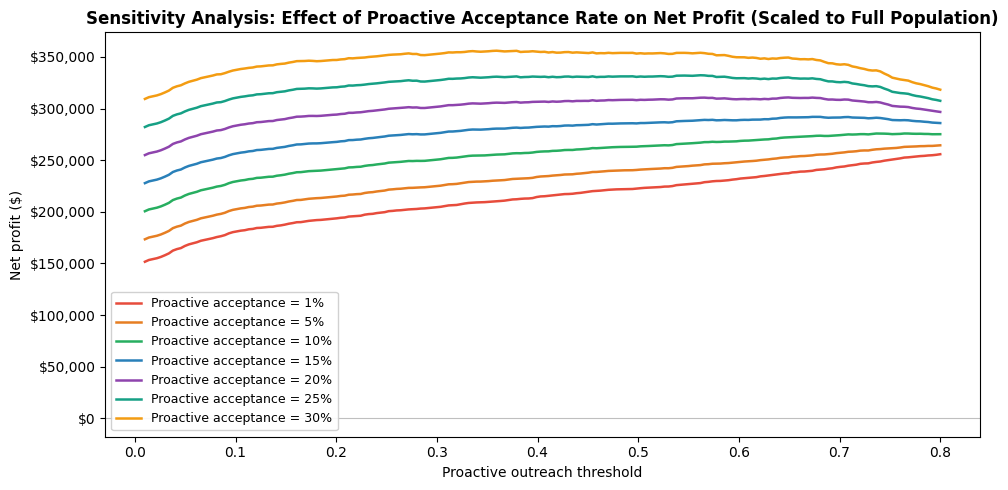

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 4: Sensitivity analysis on proactive acceptance rate ────────────
# The 25% assumption is your biggest uncertainty.

accept_rates = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Ensure we have enough colors for each rate
colors_sens = ["#e74c3c", "#e67e22", "#27ae60", "#2980b9", "#8e44ad", "#16a085", "#f39c12"]

fig, ax = plt.subplots(figsize=(10, 5))

for rate, col in zip(accept_rates, colors_sens):
    profits = []
    for t in thresholds:
        pm = (y_prob >= t)         # proactive outreach
        tp = pm & (y_true == 1)    # true positives reached proactively
        n_tp_s = tp.sum()
        n_fn_s = n_churners - n_tp_s

        # Proactive revenue & cost
        pro_rev  = (clv[tp] * rate).sum()
        pro_cost = pm.sum() * PROACTIVE_COST

        # Reactive revenue & cost
        n_react    = n_tp_s * (1 - rate) + n_fn_s
        react_rev  = n_react * REACTIVE_ACCEPT * clv[y_true == 1].mean()
        react_cost = n_react * VOUCHER_COST

        # Scale profits to the full customer population
        scaled_profit = (pro_rev + react_rev - pro_cost - react_cost) * Customer_scale_factor
        profits.append(scaled_profit)

    ax.plot(thresholds, profits, color=col, lw=1.8,
            label=f"Proactive acceptance = {int(rate*100)}%")

# Formatting
ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Proactive outreach threshold")
ax.set_ylabel("Net profit ($)")
ax.set_title(
    "Sensitivity Analysis: Effect of Proactive Acceptance Rate on Net Profit (Scaled to Full Population)",
    fontsize=12, fontweight="bold"
)
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig("sensitivity_acceptance_rate.png", dpi=150, bbox_inches="tight")
plt.show()

#### This shows the proactive net profit instead of total net profit

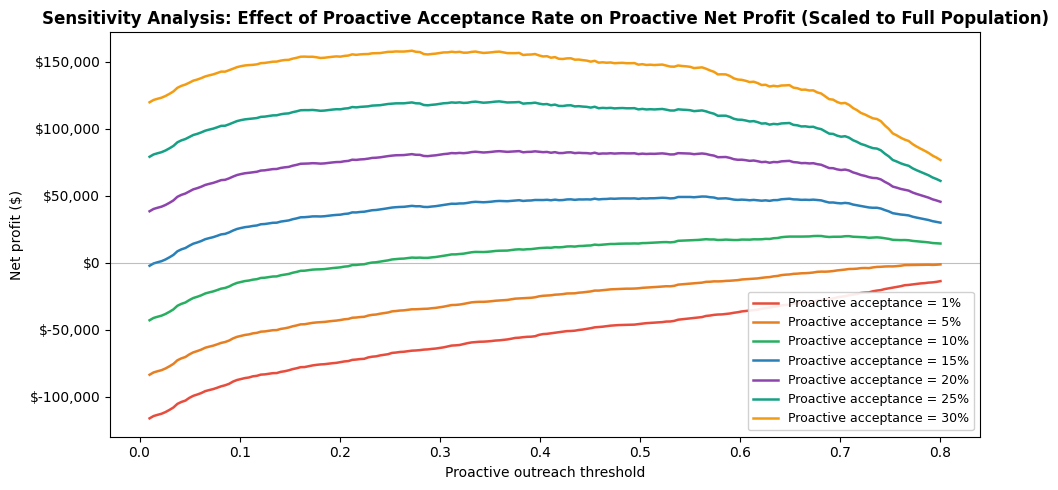

In [52]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 4: Sensitivity analysis on proactive acceptance rate ────────────
# The 25% assumption is your biggest uncertainty.

accept_rates = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Ensure we have enough colors for each rate
colors_sens = ["#e74c3c", "#e67e22", "#27ae60", "#2980b9", "#8e44ad", "#16a085", "#f39c12"]

fig, ax = plt.subplots(figsize=(10, 5))

for rate, col in zip(accept_rates, colors_sens):
    profits = []
    for t in thresholds:
        pm = (y_prob >= t)         # proactive outreach
        tp = pm & (y_true == 1)    # true positives reached proactively
        n_tp_s = tp.sum()
        n_fn_s = n_churners - n_tp_s

        # Proactive revenue & cost
        pro_rev  = (clv[tp] * rate).sum()
        pro_cost = pm.sum() * PROACTIVE_COST

        # Reactive revenue & cost
        # These are now excluded from the profit calculation as per user request
        n_react    = n_tp_s * (1 - rate) + n_fn_s
        react_rev  = n_react * REACTIVE_ACCEPT * clv[y_true == 1].mean()
        react_cost = n_react * VOUCHER_COST

        # Scale profits to the full customer population, only considering proactive components
        scaled_profit = (pro_rev - pro_cost) * Customer_scale_factor
        profits.append(scaled_profit)

    ax.plot(thresholds, profits, color=col, lw=1.8,
            label=f"Proactive acceptance = {int(rate*100)}%")

# Formatting
ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Proactive outreach threshold")
ax.set_ylabel("Net profit ($)")
ax.set_title(
    "Sensitivity Analysis: Effect of Proactive Acceptance Rate on Proactive Net Profit (Scaled to Full Population)",
    fontsize=12, fontweight="bold"
)
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig("sensitivity_acceptance_rate.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
import numpy as np
import pandas as pd

# Reuse variables from previous cells (assuming they are in the kernel state)
# y_prob, y_true, clv, PROACTIVE_COST, VOUCHER_COST, REACTIVE_ACCEPT, Customer_scale_factor, best_row_scaled

def calculate_profit_at_threshold(y_true, y_prob, clv, n_churners_test_set, proactive_accept_rate, threshold, proactive_cost_per_customer, voucher_cost, reactive_accept_rate, customer_scale_factor):
    proactive_mask = (y_prob >= threshold)
    tp_proactive = proactive_mask & (y_true == 1)

    # Proactive intervention
    # Revenue: churners who accept the proactive offer
    proactive_revenue = (clv[tp_proactive] * proactive_accept_rate).sum()
    # Cost: everyone we contact pays proactive_cost_per_customer
    proactive_cost = proactive_mask.sum() * proactive_cost_per_customer

    # Reactive voucher (backstop)
    n_tp = tp_proactive.sum()
    n_fn = n_churners_test_set - n_tp

    n_reactive_pool = (n_tp * (1 - proactive_accept_rate)) + n_fn

    # Average CLV for reactive pool (mix of TP remainder + all FN)
    # Use overall churner average CLV as approximation
    avg_clv_churner = clv[y_true == 1].mean()
    reactive_revenue = n_reactive_pool * reactive_accept_rate * avg_clv_churner
    reactive_cost = n_reactive_pool * voucher_cost

    total_revenue = proactive_revenue + reactive_revenue
    total_cost = proactive_cost + reactive_cost
    net_profit = total_revenue - total_cost

    return net_profit * customer_scale_factor

# Get the optimal threshold for the 25% acceptance rate (from best_row_scaled)
optimal_threshold = best_row_scaled['threshold'] # This is approximately 0.56
n_churners_test_set = (y_true == 1).sum()

# Calculate profit for 25% acceptance at this threshold
profit_25_percent = calculate_profit_at_threshold(
    y_true, y_prob, clv, n_churners_test_set=n_churners_test_set,
    proactive_accept_rate=0.25,
    threshold=optimal_threshold,
    proactive_cost_per_customer=PROACTIVE_COST,
    voucher_cost=VOUCHER_COST,
    reactive_accept_rate=REACTIVE_ACCEPT,
    customer_scale_factor=Customer_scale_factor
)

# Calculate profit for 10% acceptance at this threshold
profit_10_percent = calculate_profit_at_threshold(
    y_true, y_prob, clv, n_churners_test_set=n_churners_test_set,
    proactive_accept_rate=0.10,
    threshold=optimal_threshold,
    proactive_cost_per_customer=PROACTIVE_COST,
    voucher_cost=VOUCHER_COST,
    reactive_accept_rate=REACTIVE_ACCEPT,
    customer_scale_factor=Customer_scale_factor
)

difference = profit_25_percent - profit_10_percent

print(f"Net profit at threshold {optimal_threshold:.2f} with 25% proactive acceptance: ${profit_25_percent:,.0f}")
print(f"Net profit at threshold {optimal_threshold:.2f} with 10% proactive acceptance: ${profit_10_percent:,.0f}")
print(f"Difference (25% - 10%): ${difference:,.0f}")

Net profit at threshold 0.56 with 25% proactive acceptance: $332,313
Net profit at threshold 0.56 with 10% proactive acceptance: $267,041
Difference (25% - 10%): $65,273



── Customer tier breakdown (test set) ──────────────────────────────

                           tier   n avg_prob churn_rate avg_clv                                                 intervention
 Tier 1 — High risk, high value 387    77.2%      56.8%    $517        Premium proactive outreach + reserve reactive voucher
Tier 2 — High risk, lower value 134    69.7%      50.0%    $246 Cost‑efficient proactive outreach + reserve reactive voucher
           Tier 3 — Medium risk 285    41.6%      20.4%    $425                                       Soft campaign, monitor
              Tier 4 — Low risk 603    10.5%       4.8%    $312                                                    No action


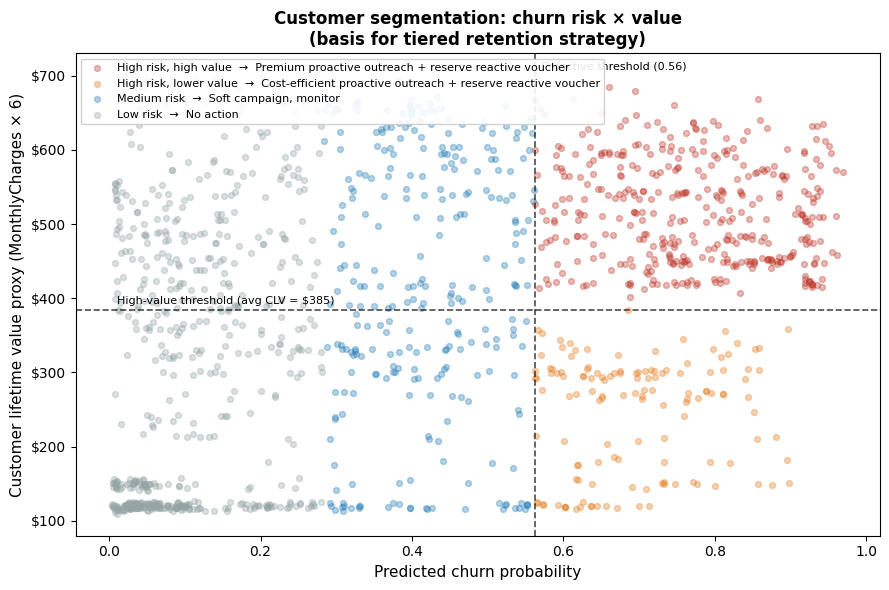

In [51]:
# ── 6: Risk × value segmentation scatter ────────────────────────────

CLV_HIGH_CUTOFF  = clv.mean()                     # above mean CLV = "high value"
HIGH_RISK_THRESH = best_row["threshold"]           # use profit-optimal threshold
MED_RISK_THRESH  = best_row["threshold"] * 0.5    # medium risk = half of optimal

test_seg = X_test.copy()
test_seg["y_true"] = y_true
test_seg["y_prob"] = y_prob
test_seg["clv"]    = clv

def assign_tier(row):
    if row["y_prob"] >= HIGH_RISK_THRESH and row["clv"] >= CLV_HIGH_CUTOFF:
        return "Tier 1 — High risk, high value"
    elif row["y_prob"] >= HIGH_RISK_THRESH:
        return "Tier 2 — High risk, lower value"
    elif row["y_prob"] >= MED_RISK_THRESH:
        return "Tier 3 — Medium risk"
    else:
        return "Tier 4 — Low risk"

test_seg["tier"] = test_seg.apply(assign_tier, axis=1)

tier_summary = (
    test_seg.groupby("tier")
    .agg(n=("y_prob","count"), avg_prob=("y_prob","mean"),
         avg_clv=("clv","mean"), churners=("y_true","sum"))
    .assign(churn_rate=lambda d: d["churners"] / d["n"])
    .reset_index().sort_values("tier")
)
tier_summary["avg_clv"]   = tier_summary["avg_clv"].map("${:,.0f}".format)
tier_summary["avg_prob"]  = tier_summary["avg_prob"].map("{:.1%}".format)
tier_summary["churn_rate"]= tier_summary["churn_rate"].map("{:.1%}".format)

interventions = {
    "Tier 1 — High risk, high value":  "Premium proactive outreach + reserve reactive voucher",
    "Tier 2 — High risk, lower value": "Cost‑efficient proactive outreach + reserve reactive voucher",
    "Tier 3 — Medium risk":            "Soft campaign, monitor",
    "Tier 4 — Low risk":               "No action",
}
tier_summary["intervention"] = tier_summary["tier"].map(interventions)
print("\n── Customer tier breakdown (test set) ──────────────────────────────\n")
print(tier_summary[["tier","n","avg_prob","churn_rate","avg_clv","intervention"]].to_string(index=False))

# Scatter
colors_tier = {
    "Tier 1 — High risk, high value":  "#c0392b",
    "Tier 2 — High risk, lower value": "#e67e22",
    "Tier 3 — Medium risk":            "#2980b9",
    "Tier 4 — Low risk":               "#95a5a6",
}

fig, ax = plt.subplots(figsize=(9, 6))
for tier, grp in test_seg.groupby("tier"):
    ax.scatter(grp["y_prob"], grp["clv"],
               c=colors_tier[tier], alpha=0.35, s=18,
               label=f"{tier.split('—')[1].strip()}  →  {interventions[tier]}")

ax.axvline(HIGH_RISK_THRESH, color="black", lw=1.2, ls="--", alpha=0.7)
ax.axhline(CLV_HIGH_CUTOFF,  color="black", lw=1.2, ls="--", alpha=0.7)
ax.text(HIGH_RISK_THRESH + 0.01, ax.get_ylim()[1] * 0.97,
        f"Proactive threshold ({HIGH_RISK_THRESH:.2f})", fontsize=8)
ax.text(0.01, CLV_HIGH_CUTOFF * 1.02,
        f"High-value threshold (avg CLV = ${CLV_HIGH_CUTOFF:,.0f})", fontsize=8)

ax.set_xlabel("Predicted churn probability", fontsize=11)
ax.set_ylabel("Customer lifetime value proxy (MonthlyCharges × 6)", fontsize=11)
ax.set_title("Customer segmentation: churn risk × value\n(basis for tiered retention strategy)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=8, framealpha=0.9, loc="upper left")
plt.tight_layout()
plt.savefig("risk_value_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()